Here's an ASCII representation of the confusion matrix:
```
           Predicted
           0   |   1
         -------------
 Actual 0 | TN  |  FP
        1 | FN  |  TP
```
 Where:
- TP = True Positives
- TN = True Negatives
- FP = False Positives
- FN = False Negatives


How to remember:

When speaking of Negative or Positive, we speak about the result of our predictor.

And this results can either be True or False.


Hence, a False Positive is an erroned True prediction from our predictor.

# Example from [stratusdata.io](https://stratusdata.io/gone-fishing-4-metrics-for-evaluating-binary-classifiers/)

You’re a fisherman, and you catch tuna for a living.

The  content of the  circle is what you caught.

![](TN_TP_FP_FN.png)

## Accuracy

### Intuition

Accuracy is how well the model performs

### Formula

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

### Caution

/!\ Misleading with unbalanced classes

If dataset is 95 Positive and 5 Negative

Predicting all positive will yield 95% accuracy

Even though the model always output the same class.

#### Solution:
- [balanced accuracy (bACC)](https://en.wikipedia.org/wiki/Precision_and_recall#:~:text=Precision%20and%20recall%20are%20not,number%20of%20extremely%20likely%20items.) normalizes true positive and true negative predictions by the number of positive and negative samples, respectively, and divides their sum by two:
$$
{\displaystyle {\text{Balanced accuracy}}={\frac {TPR+TNR}{2}}\,}
$$

With: 

True positive rate (TPR), TP out of all True samples.

$$
TPR = \frac{TP}{TP + FN}
$$

True negative rate (TNR), TN out of all Negative samples.

$$
TNR = \frac{TN}{TN + FP}
$$


![](https://upload.wikimedia.org/wikipedia/commons/thumb/2/26/Precisionrecall.svg/525px-Precisionrecall.svg.png) 


## Precision



### Intuition :
- How often are we correct in our positive prediction?
- How many positives were correctly classified ?
### Formula :
$$
\text{Precision} = \frac{TP}{TP + FP}
$$
### Use case:
- When the cost of False Positive is high.
- Example:
  - Cancer detection (before starting treatment)
  - Judgement (we do not want to condemn an innocent person)
  - Recruitment
### Caution : 
- We are blind on the performance of any negative prediction

## Recall 

Also named `True Positive Rate (TPR)` or `Sensitivity`

### Intuition :
- How often did we wrongly classify something as not true (= false)?
- How often did we miss classifying a true item ?

### Formula :
$$
\text{Recall} = \frac{TP}{TP + FN}
$$
### Use case:
- When the cost of False Negative is high.
  - Example:
    - Cancer detection (test screening)
    - Fraud detection (annoying a customer high spending might be less problematic, than letting pass a fraud which wipes out its life savings)

### Caution : 
  - We are blind on the performance on any False data points in our dataset.

## F1_score:
- Utilize the precision and recall to create a test’s accuracy through the “harmonic mean”.
- It focuses on the on the left-bottom to right-top diagonal in the Confusion Matrix.

### Formula

$$
\text{F}_1 = 2 * \left( \frac{\text{Precision} * \text{Recall}}{\text{Precision} + \text{Recall}} \right)
$$

To favor precision or recall:

$$
F_{\beta }=(1+\beta ^{2})\cdot {\frac {\mathrm {precision} \cdot \mathrm {recall} }{\beta ^{2}\cdot \mathrm {precision} +\mathrm {recall} }}
$$

$F_{2}$ favors recall.

$F_{0.5}$ favors precision.


ROC - AUC

## ROC curve:

Receiver Operating Characteristic curve

![](https://en.wikipedia.org/wiki/File:Roccurves.png)

It plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold.


### True positive rate (TPR)

It's recall formula.

Answers the question: How many True values were correctly predicted as positive?


$$
\text{TPR} = \frac{TP}{TP + FN}
$$


### False positive rate (FPR)

How many False values were wrongly predicted as positive?

$$
\text{FPR} = \frac{FP}{FP + TN}
$$

![](https://upload.wikimedia.org/wikipedia/commons/thumb/1/13/Roc_curve.svg/330px-Roc_curve.svg.png)

## AUC:


### ROC-AUC:

Area under the curve

It's the area under the ROC curve.

![](https://developers.google.com/static/machine-learning/crash-course/images/auc_1-0.png)
![](https://developers.google.com/static/machine-learning/crash-course/images/auc_0-5.png)
![](https://developers.google.com/static/machine-learning/crash-course/images/auc_0-31.png)
![](https://developers.google.com/static/machine-learning/crash-course/images/auc_0-77.png)

### ROC-PRC:

Precision Recall Curve

![](https://developers.google.com/static/machine-learning/crash-course/images/prauc.png)

Usefull when the classes are imbalanced.


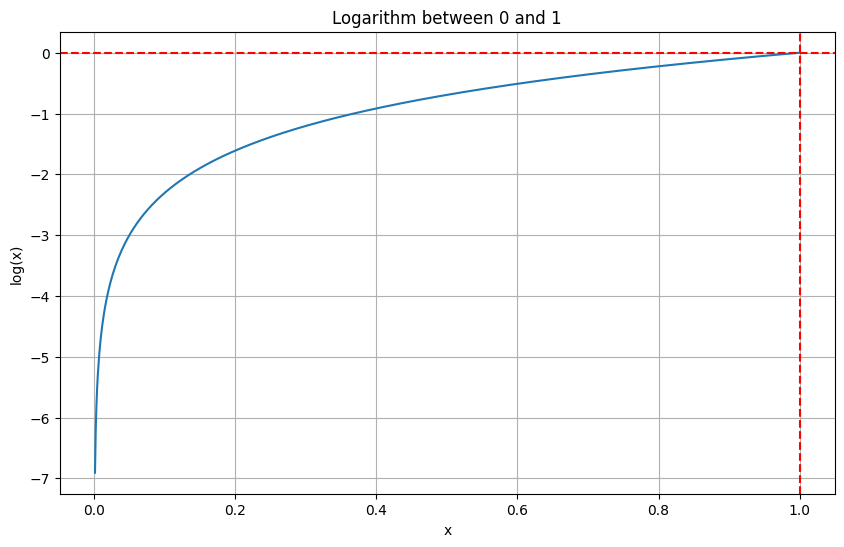

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values between 0 and 1
x = np.linspace(0.001, 1, 1000)  # Start from 0.001 to avoid log(0)

# Calculate logarithm
y = np.log(x)

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.title('Logarithm between 0 and 1')
plt.xlabel('x')
plt.ylabel('log(x)')
plt.grid(True)
plt.axhline(y=0, color='r', linestyle='--')  # Add horizontal line at y=0
plt.axvline(x=1, color='r', linestyle='--')  # Add vertical line at x=1
plt.show()


## Log Loss

Formula:

$$
\text{Log Loss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]
$$

R**2 : 

https://en.wikipedia.org/wiki/Coefficient_of_determination 

https://medium.com/@brandon93.w/regression-model-evaluation-metrics-r-squared-adjusted-r-squared-mse-rmse-and-mae-24dcc0e4cbd3



In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, log_loss, r2_score
from ipywidgets import interact, widgets, interactive, fixed, interact_manual
import numpy as np

# Generate classification dataset
X, y = make_classification(
    n_samples=100,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=1,
    random_state=42,
)
X = X.flatten()  # Flatten X to 1D array

X += np.random.normal(0, 1, len(X))
X[y == 1] += 0.6
X -= X.min()
X /= X.max()


fpr, tpr, thresholds = roc_curve(y, X)
roc_auc = auc(fpr, tpr)

In [3]:
@interact(
    threshold=widgets.FloatSlider(
        min=0,
        max=1,
        value=.5,
    )
)
def interactive_classification(threshold):
    # Create figure with 3 subplots
    fig = plt.figure(figsize=(15, 15))
    ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
    # ax2 = plt.subplot2grid((2, 2), (0, 1))
    ax3 = plt.subplot2grid((2, 2), (1, 0))
    ax4 = plt.subplot2grid((2, 2), (1, 1))

    # First axis: Scatterplot
    colors = ['darkred' if (X[i] >= threshold) != y[i] else 'darkgreen' for i in range(len(y))]
    markers = ['o' if y[i] == 1 else 's' for i in range(len(y))]

    jitter = (np.random.rand(len(y)) * .1) -.05

    # Add background colors
    ax1.axvspan(0, threshold, facecolor='lightcoral', alpha=0.3)
    ax1.axvspan(threshold, 1, facecolor='lightgreen', alpha=0.3)

    for i, (color, marker, x, y_val) in enumerate(zip(colors, markers, X, y)):
        ax1.scatter(x, y_val + jitter[i], c=color, marker=marker, alpha=0.6)

    ax1.axvline(x=threshold, color='black', linestyle='--')
    ax1.set_xlabel('Predicted Values')
    ax1.set_ylabel('Truth Values')
    ax1.set_title('Truth vs Predicted Values')
    ax1.set_xlim(0, 1)  # Ensure the x-axis limits are set to 0 and 1

    # Second axis: Classification Report and Metrics
    y_pred = (X >= threshold).astype(int)
    report = classification_report(y, y_pred, output_dict=True)
    cm = confusion_matrix(y, y_pred)

    # Extract values from confusion matrix
    TN, FP, FN, FN = cm.ravel()


    # Calculate additional metrics
    fpr_at_threshold = fpr[np.argmin(np.abs(thresholds - threshold))]
    tpr_at_threshold = tpr[np.argmin(np.abs(thresholds - threshold))]
    r2 = r2_score(y, X)
    log_loss_val = log_loss(y, X)

    # Format the text
    text = f"""Classification Report:
Accuracy:  {report['accuracy']:.3f} ({FN=} + {TN=} / ({FN=} + {TN=} + {FP=} + {FN=}))
Precision: {report['weighted avg']['precision']:.3f} ({FN=} / ({FN=} + {FP=}))
Recall:    {report['weighted avg']['recall']:.3f} ({FN=} / ({FN=} + {FN=}))
F1 Score:  {report['weighted avg']['f1-score']:.3f} (2 * {FN=} / (2 * {FN=} + {FP=} + {FN=}))

Additional Metrics:
FPR:       {fpr_at_threshold:.3f} ({FP} / ({FP + TN}))
TPR:       {tpr_at_threshold:.3f} ({FN} / ({FN + FN}))
R2 Score:  {r2:.3f}
Log Loss:  {log_loss_val:.3f}
AUC:       {roc_auc:.3f}"""
    print(text)

    # ax2.text(0.05, 0.95, text, transform=ax2.transAxes, fontsize=10,
    #          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    # ax2.axis('off')
    # ax2.set_title('Classification Metrics')

    # Third axis: Confusion Matrix Heatmap
    y_pred = (X >= threshold).astype(int)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=sns.cubehelix_palette(as_cmap=True), ax=ax3
    )
    ax3.set_xlabel('Predicted')
    ax3.set_ylabel('Truth')
    ax3.set_title('Confusion Matrix')

    # Fourth axis: ROC-AUC Curve

    ax4.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax4.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax4.axvline(x=fpr[np.argmin(np.abs(thresholds - threshold))], color='red', linestyle='--', label=f'Threshold ({threshold:.2f})')
    ax4.set_xlim([0.0, 1.0])
    ax4.set_ylim([0.0, 1.05])
    ax4.set_xlabel('False Positive Rate')
    ax4.set_ylabel('True Positive Rate')
    ax4.set_title('ROC Curve')
    ax4.legend(loc="lower right")

    # plt.tight_layout()
    # plt.show()

interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0), Output()), _dom_classes=('widg…